In [1]:
import sys
sys.path.append('..')
import numpy as np
import brainpy as bp
import brainpy.math as bm
import matplotlib.pyplot as plt
from CANN_DDM_model import CANN_DDM_model
from tqdm import tqdm
import pickle
import seaborn as sns
import json
import matplotlib.ticker as mticker

import matplotlib.lines as mlines

/projectnb/ecog-eeg/cyw6/.conda/envs/cann_ddm_v2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Decision variable trajectory simulated by Drift diffusion model (DDM)

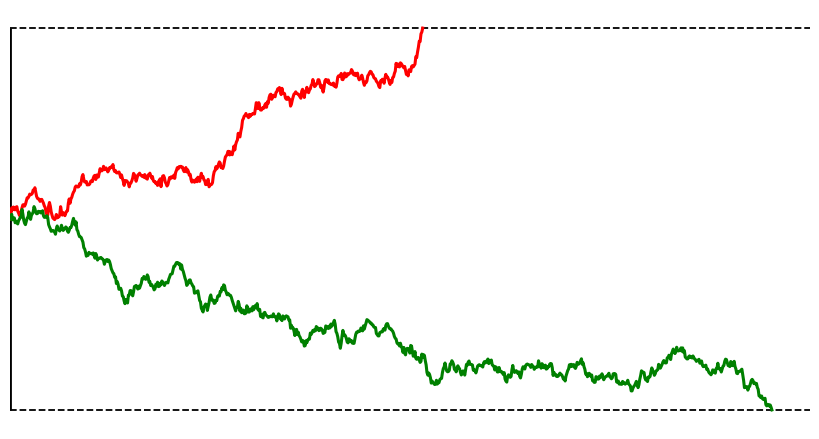

In [2]:
rng = np.random.default_rng(20251010)

A1 = 1   # positive drift -> upper boundary
A2 = -1  # negative drift -> lower boundary
sigma = 0.25
dt = 1e-3
x0 = 0.5
lower, upper = 0.0, 1.0
t_max = 2.0

def simulate_trial(A, sigma, dt, x0, lower, upper, t_max, rng):
    n_steps = int(t_max / dt)
    x = x0
    xs = [x0]
    ts = [0.0]
    for i in range(1, n_steps + 1):
        dW = rng.normal(0.0, np.sqrt(dt))
        x = x + A*dt + sigma * dW
        if x >= upper:
            x = upper; xs.append(x); ts.append(i*dt); break
        elif x <= lower:
            x = lower; xs.append(x); ts.append(i*dt); break
        else:
            xs.append(x); ts.append(i*dt)
    return np.array(ts), np.array(xs)

# simulate both
t_u, x_u = simulate_trial(A1, sigma, dt, x0, lower, upper, t_max, rng)
t_l, x_l = simulate_trial(A2, sigma, dt, x0, lower, upper, t_max, rng)

plt.figure(figsize=(8, 4.2))
Tmax = max(t_u[-1], t_l[-1]) * 1.05

# black boundaries
plt.plot([0, Tmax], [upper, upper], linestyle='--', linewidth=1.3, color='black')
plt.plot([0, Tmax], [lower, lower], linestyle='--', linewidth=1.3, color='black')

# curves
plt.xlabel('Time (s)')
plt.ylabel('Decision variable')
plt.vlines(0, 0 ,1, linewidth=2, color='black')
plt.plot(t_u, x_u, linewidth=2.2, color='red')
plt.plot(t_l, x_l, linewidth=2.2, color='green')

plt.axis('off')
plt.xlim(0, Tmax)
plt.ylim(-0.05, 1.05)
plt.tight_layout(pad=0)

## Our neural circuit model perfectly encodes the decision variable in DDM

In [4]:
with open('../results/model_config_default.json') as data:
    CANN_params = json.load(data)
    decision_space_params = CANN_params['decision_space_params']
    edge_pop = CANN_params['edge_pop']
    bump_pop = CANN_params['bump_pop']

In [5]:
pos_offset = 0.03
t_start = 200
# drift_rate = -1
decision_space_params.update({'seed': 2024, 'drift_rate': 0.9})
CANN_params.update({'decision_space_params': decision_space_params})
model = CANN_DDM_model(CANN_params = CANN_params)

mon_vars = ['theta_B', 'theta_E', 'hit_boundary', 'x_B', 'x_E', 'c_BE_dyn', 'r_E', 'r_B']
runner_1, RT_1 = model.run_simulation(mon_vars = mon_vars, progress_bar=True, pos_offset = pos_offset, get_RT=True)


times_1 = np.arange(RT_1)
r_E_1 = runner_1.mon.r_E[t_start:int(t_start+RT_1), :]
r_B_1 = runner_1.mon.r_B[t_start:int(t_start+RT_1), :]
x_B_1 = runner_1.mon.x_B[t_start:int(t_start+RT_1), 0]
x_E_1 = runner_1.mon.x_E[t_start:int(t_start+RT_1), 0]
theta_B_1 = runner_1.mon.theta_B[t_start:int(t_start+RT_1)]
theta_E_1 = runner_1.mon.theta_E[t_start:int(t_start+RT_1)]
x_traj_1 = model.x_traj[t_start:int(t_start+RT_1)]

# drift_rate = -1
decision_space_params.update({'seed': 2025, 'drift_rate': -0.9})
CANN_params.update({'decision_space_params': decision_space_params})
model = CANN_DDM_model(CANN_params = CANN_params)
runner_2, RT_2 = model.run_simulation(mon_vars = mon_vars, progress_bar=True, pos_offset = pos_offset, get_RT=True)
times_2 = np.arange(RT_2)
r_E_2 = runner_2.mon.r_E[t_start:int(t_start+RT_2), :]
r_B_2 = runner_2.mon.r_B[t_start:int(t_start+RT_2), :]
x_B_2 = runner_2.mon.x_B[t_start:int(t_start+RT_2), 0]
x_E_2 = runner_2.mon.x_E[t_start:int(t_start+RT_2), 0]
theta_B_2 = runner_2.mon.theta_B[t_start:int(t_start+RT_2)]
theta_E_2 = runner_2.mon.theta_E[t_start:int(t_start+RT_2)]

x_traj_2 = model.x_traj[t_start:int(t_start+RT_2)]
x_traj_2[x_traj_2 < x_B_2.min()] = x_B_2.min()
cue_R_all_2 = model.cue_R_all[t_start:int(t_start+RT_2)]
cue_L_all_2 = model.cue_L_all[t_start:int(t_start+RT_2)]


Predict 1100 steps: : 100%|██████████| 1100/1100 [00:00<00:00, 1254.75it/s]


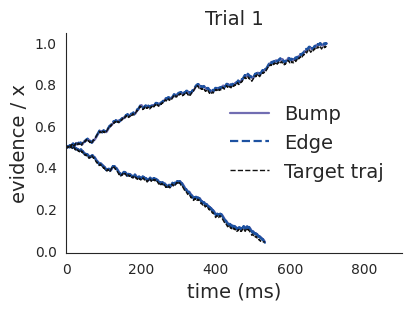

In [6]:
sns.set_style('white')
#x_B_2 = 0.5 * (x_B_2 - x_B_2.min()) / (x_B_2.max() - x_B_2.min())
#x_E_2 = 0.5 * (x_E_2 - x_E_2.min()) / (x_E_2.max() - x_E_2.min())
colors = {'bump':'#716db2', 'edge':'#1d52a1', 'traj':'#111111'}

fig, axes = plt.subplots(1, 1, figsize=(4, 3), sharey=True, constrained_layout=True)
ax1 = axes

# Trial 1
times1 = np.arange(len(x_B_1))
times2 = np.arange(len(x_B_2))
ax1.plot(times1, x_B_1, color=colors['bump'], lw=1.6, label='Bump', linestyle='-')
ax1.plot(times1, x_E_1, color=colors['edge'], lw=1.6, label='Edge', linestyle='--')
ax1.plot(times2, x_B_2, color=colors['bump'], lw=1.6)
ax1.plot(times2, x_E_2, color=colors['edge'], lw=1.6)
ax1.plot(times1, x_traj_1, color=colors['traj'], lw=1, linestyle='--', label='Target traj')
ax1.plot(times2, x_traj_2, color=colors['traj'], lw=1, linestyle='--')
ax1.set_title('Trial 1', fontsize=14)
ax1.set_xlabel('time (ms)', fontsize=14)
ax1.set_ylabel('evidence / x', fontsize=14)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.set_xlim(0, 900)
ax1.tick_params(direction='out')
ax1.legend(frameon=False, fontsize=14)

# # Trial 2
# times2 = np.arange(len(x_B_2))
# ax2.plot(times2, x_B_2, color=colors['bump'], lw=1.6, label='Bump (trial 2)')
# ax2.plot(times2, x_E_2, color=colors['edge'], lw=1.6, label='Edge (trial 2)')
# ax2.plot(times2, x_traj_2, color=colors['traj'], lw=1.25, linestyle='--', label='Target traj')
# ax2.set_title('Trial 2', fontsize=14)
# ax2.set_xlabel('time (ms)', fontsize=14)
# ax2.spines['top'].set_visible(False)
# ax2.spines['right'].set_visible(False)
# ax2.tick_params(direction='out')
# ax2.legend(frameon=False, fontsize=14)

plt.show()

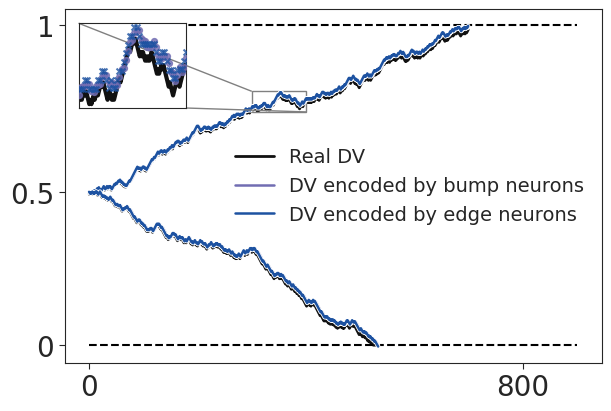

In [8]:
import matplotlib.patheffects as pe
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

# 颜色 & 风格

colors = {'bump':'#716db2', 'edge':'#1d52a1', 'traj':'#111111'}
#colors = {'bump':'red', 'edge':'green', 'traj':'#111111'}
pe_halo = [pe.withStroke(linewidth=3, foreground='white')]

fig = plt.figure(figsize=(6,4), constrained_layout=True)
gs = fig.add_gridspec(nrows=1, ncols=1)  # 改成 1 行
ax = fig.add_subplot(gs[0])

# 主面板：GT 粗灰实线在下层
ax.plot(times_1, x_traj_1, lw=2.0, color=colors['traj'], alpha=1, zorder=1, label='Real DV ')
ax.plot(times_2, x_traj_2, lw=2.0, color=colors['traj'], alpha=1, zorder=1)
ax.hlines(x_B_2.min(), 0, 900, lw=1.5, color='black', zorder=1, linestyle='--')
ax.hlines(1, 0, 900, lw=1.5, color='black', zorder=1, linestyle='--')


ax.set_xticks([0, 800])
ax.set_xticklabels(['0', '800'], fontsize=20)
ax.set_yticks([x_B_2.min(), 0.5, 1])
ax.set_yticklabels([0, 0.5, 1], fontsize=20)
# bump：点划线 + 稀疏圆点 + 白描边
line_b_1, = ax.plot(times_1, x_B_1, lw=1.8, color=colors['bump'], linestyle='-', zorder=3,
                  path_effects=pe_halo, label='DV encoded by bump neurons')
line_b_2, = ax.plot(times_2, x_B_2, lw=1.8, color=colors['bump'], linestyle='-', zorder=3,
                  path_effects=pe_halo)
#ax.scatter(times1[::8], x_B_1[::8], s=20, color=colors['bump'], zorder=4)

# edge：虚线 + 稀疏叉号 + 白描边
line_e_1, = ax.plot(times_1, x_E_1, lw=1.8, color=colors['edge'], linestyle='-', zorder=3,
                  path_effects=pe_halo, label='DV encoded by edge neurons')
line_e_2, = ax.plot(times_2, x_E_2, lw=1.8, color=colors['edge'], linestyle='-', zorder=3,
                  path_effects=pe_halo)
#ax.scatter(times1[::8], x_E_1[::8], s=20, marker='x', color=colors['edge'], zorder=4)

# 局部放大（选择一段重合最明显的时间窗）
axins = inset_axes(ax, width="20%", height="24%", loc='upper left', borderpad=1.0)
t0, t1 = 300, 400
mask = (times_1>=t0) & (times_1<=t1)
axins.plot(times_1[mask], x_traj_1[mask], lw=3.0, color=colors['traj'], alpha=1, zorder=2)
#axins.plot(times1[mask], x_B_1[mask], lw=1.8, color=colors['bump'], linestyle='-.', zorder=3, path_effects=pe_halo)
#axins.plot(times1[mask], x_E_1[mask], lw=1.8, color=colors['edge'], linestyle='--', zorder=3, path_effects=pe_halo)
axins.scatter(times_1[mask][::2], x_B_1[mask][::2], s=18, color=colors['bump'], zorder=4, alpha=0.8)
axins.scatter(times_1[mask][::2], x_E_1[mask][::2], s=18, marker='x', color=colors['edge'], zorder=4, alpha=0.8)
axins.set_xlim(t0, t1)
axins.set_xticks([])
axins.set_yticks([])
mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.5")


# 主面板细节
#ax.set_ylabel(r'Decision variable, $x$', fontsize=14)
#ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.tick_params(axis='x', bottom=True, labelbottom=True, length=4)
ax.tick_params(axis='y', left=True, labelleft=True, length=4)


# ax.xaxis.set_major_locator(mticker.FixedLocator([50, 800]))
# ax.xaxis.set_major_formatter(mticker.FixedFormatter(['0', '750']))
# 可选：去掉主图图例
ax.legend(frameon=False, loc='center right', fontsize=14)
#plt.savefig('../figs/DDM_traj.png', dpi=1000)
plt.savefig("../figs/DDM_traj.pdf", bbox_inches="tight")

plt.show()


/scratch/ipykernel_3530259/478905024.py:91: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  im1 = ax_tl.imshow(
/scratch/ipykernel_3530259/478905024.py:100: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  im2 = ax_bl.imshow(


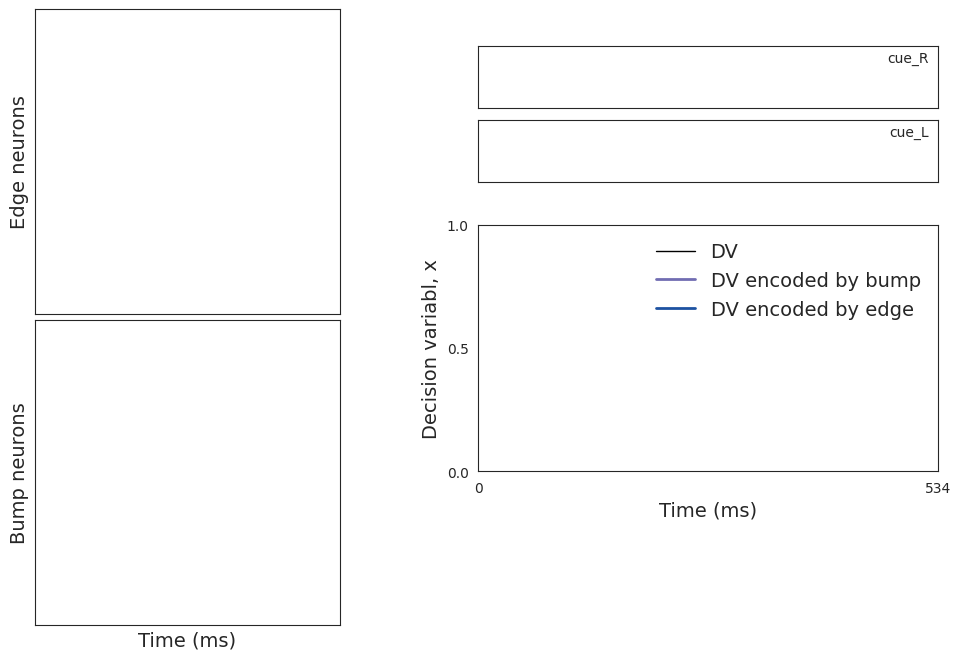

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

fontsize=14
# ===============================
# Assumptions (already defined):
# r_E_2, times_2, theta_E_2
# r_B_2, times_2, theta_B_2
# x_traj_2
# cue_R_all_2, cue_L_all_2   # binary (0/1) arrays, same length as times_2
# x_B_2, x_E_2
# model, N_start
# colors, RT_2
# ===============================

col_start = 200
col_end   = 600
stride = 10
interval_ms = 50

# ---- Prepare heatmaps ----
H1 = r_E_2[:, col_start:col_end].T   # (N1, T)
H2 = r_B_2[:, col_start:col_end].T   # (N2, T)

n1, T1 = H1.shape
n2, T2 = H2.shape

assert T2 == len(x_traj_2)
assert T2 == len(times_2)
assert T2 == len(cue_R_all_2)
assert T2 == len(cue_L_all_2)

# trajectories (red lines)
traj1 = model.pos_to_idx(theta_E_2) - col_start
traj2 = model.pos_to_idx(theta_B_2) - col_start

# frames (shared master timeline = times_2)
frames = np.arange(0, T2, stride)
if frames[-1] != T2 - 1:
    frames = np.append(frames, T2 - 1)

# ---- Figure layout ----
fig = plt.figure(figsize=(12, 8))
# outer: left vs right
gs = fig.add_gridspec(
    1, 2,
    width_ratios=[8, 6],
    wspace=0.08
)

# left column: stacked square heatmaps
gs_left = gs[0].subgridspec(
    2, 1,
    hspace=0.02
)

ax_tl = fig.add_subplot(gs_left[0])
ax_bl = fig.add_subplot(gs_left[1])

# Right-side container axis spans both rows; it will be blank.
ax_r_container = fig.add_subplot(gs[1])
ax_r_container.set_axis_off()

# ------------------------------------------------------------
# Split the original cue axis into TWO stacked cue axes:
# - Same overall width/position as before
# - Each one slightly less than half the original height
# ------------------------------------------------------------
# Original cue: [0.0, 0.72, 1.3, 0.22]
# Make two axes with a small gap between them.
cue_x0, cue_y0, cue_w, cue_h = 0.0, 0.72, 1.2, 0.22
gap = 0.02                 # gap in container coords
each_h = (cue_h - gap) / 2 # each subplot a bit less than half of original

ax_cue_top = ax_r_container.inset_axes([cue_x0, cue_y0 + each_h + gap, cue_w, each_h])
ax_cue_bot = ax_r_container.inset_axes([cue_x0, cue_y0,               cue_w, each_h])

# Middle-right x_traj axis, keep centered (your current placement)
ax_r = ax_r_container.inset_axes([0.0, 0.25, 1.2, 0.40])

# ---- Remove frames for heatmaps ----
for ax in (ax_tl, ax_bl):
    # ax.set_frame_on(False)
    # for s in ax.spines.values():
    #     s.set_visible(False)
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    ax.set_box_aspect(1)

# ---- Initial (invisible) images ----
im1 = ax_tl.imshow(
    H1[:, :1], origin="lower", cmap="viridis",
    vmin=np.min(H1), vmax=np.max(H1),
    extent=[times_2[0], times_2[0], 0, n1],
    aspect='auto'
)
im1.set_visible(False)
im1.set_clip_on(False)

im2 = ax_bl.imshow(
    H2[:, :1], origin="lower", cmap="viridis",
    vmin=np.min(H2), vmax=np.max(H2),
    extent=[times_2[0], times_2[0], 0, n2],
    aspect='auto'
)
im2.set_visible(False)
im2.set_clip_on(False)

# ---- Red trajectories ----
(line1,) = ax_tl.plot([], [], color=colors['edge'], lw=2)
(line2,) = ax_bl.plot([], [], color=colors['bump'], lw=2)

ax_tl.set_ylim(0, n1)
ax_bl.set_ylim(0, n2)
ax_tl.set_xlim(times_2[0], times_2[-1])
ax_bl.set_xlim(times_2[0], times_2[-1])

ax_tl.set_xticks([])
ax_bl.set_xticks([0, RT_2])
ax_bl.set_xlabel("Time (ms)", fontsize=fontsize)
ax_tl.set_ylabel("Edge neurons", fontsize=fontsize)
ax_bl.set_ylabel("Bump neurons", fontsize=fontsize)

# ---- Configure the TWO cue axes (binary step) ----
for ax in (ax_cue_top, ax_cue_bot):
    # clean look
    # ax.set_frame_on(False)
    # for s in ax.spines.values():
    #     s.set_visible(False)
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    ax.set_xlim(times_2[0], times_2[-1])
    ax.set_ylim(-0.1, 1.1)
    ax.set_xticks([])

# Top cue: cue_R
(cueR_line,) = ax_cue_top.plot([], [], drawstyle="steps-post", lw=1.2, color='green', alpha=1)
ax_cue_top.text(0.98, 0.80, "cue_R", transform=ax_cue_top.transAxes,
                ha="right", va="center", fontsize=10)

# Bottom cue: cue_L
(cueL_line,) = ax_cue_bot.plot([], [], drawstyle="steps-post", lw=1.2, color='red', alpha=1)
ax_cue_bot.text(0.98, 0.80, "cue_L", transform=ax_cue_bot.transAxes,
                ha="right", va="center", fontsize=10)

# ---- Middle-right x_traj_2 time series ----
(x_line,)   = ax_r.plot([], [], color='black', lw=1.0, label='DV')
(x_line_B,) = ax_r.plot([], [], color=colors['bump'], lw=2.0, label='DV encoded by bump')
(x_line_E,) = ax_r.plot([], [], color=colors['edge'], lw=2.0, label='DV encoded by edge')

# Clean right axis (keep your labels/ticks)
ax_r.set_xlim(times_2[0], times_2[-1])
ax_r.set_ylim(0, 1)
ax_r.set_yticks([0, 0.5, 1])
ax_r.set_xticks([0, RT_2])
ax_r.set_xlabel("Time (ms)", fontsize=fontsize)
ax_r.set_ylabel("Decision variabl, x", fontsize=fontsize)
ax_r.legend(frameon=False, fontsize=14)
# Optional: remove frame from ax_r but keep ticks/labels
# ax_r.set_frame_on(False)
# for s in ax_r.spines.values():
#     s.set_visible(False)

# ---- Animation update ----
def update(k):
    if k == 0:
        return ()

    # Bottom-left heatmap (Bump)
    im2.set_visible(True)
    im2.set_data(H2[:, :k+1])
    im2.set_extent([times_2[0], times_2[k], 0, n2])
    line2.set_data(times_2[:k+1], traj2[:k+1])

    # Top-left heatmap (Edge)
    k1 = min(k, T1 - 1)
    im1.set_visible(True)
    im1.set_data(H1[:, :k1+1])
    im1.set_extent([times_2[0], times_2[k1], 0, n1])
    line1.set_data(times_2[:k1+1], traj1[:k1+1])

    # Two cue axes (reveal)
    cueR_line.set_data(times_2[:k+1], cue_R_all_2[:k+1])
    cueL_line.set_data(times_2[:k+1], cue_L_all_2[:k+1])

    # Middle-right x_traj_2 (reveal)
    x_line.set_data(times_2[:k+1], x_traj_2[:k+1])
    x_line_B.set_data(times_2[:k+1], x_B_2[:k+1])
    x_line_E.set_data(times_2[:k+1], x_E_2[:k+1])

    return im1, im2, line1, line2, cueR_line, cueL_line, x_line, x_line_B, x_line_E

anim = FuncAnimation(
    fig,
    update,
    frames=frames,
    interval=interval_ms,
    blit=False
)

plt.show()

# Save (gif)
